In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 1. Load Dataset & Basic Exploration
df = pd.read_csv(r"C:\Users\admin\Downloads\Excelr Assignment\EDA2\EDA2\adult_with_headers.csv")
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [5]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
# Scaling Numerical Features
num_features = ["age", "fnlwgt", "education_num", 
                "capital_gain", "capital_loss", "hours_per_week"]

df_num = df[num_features]

# Standard Scaling (mean=0, std=1)
scaler_standard = StandardScaler()
df_standard_scaled = pd.DataFrame(scaler_standard.fit_transform(df_num),
                                  columns=num_features)

# Min-Max Scaling (0–1 range)
scaler_minmax = MinMaxScaler()
df_minmax_scaled = pd.DataFrame(scaler_minmax.fit_transform(df_num),
                                columns=num_features)

print("\nStandard Scaled Data (first 5 rows):\n", df_standard_scaled.head())
print("\nMin-Max Scaled Data (first 5 rows):\n", df_minmax_scaled.head())

# Discussion:
# - Standard Scaling is useful for algorithms sensitive to variance (SVM, PCA, KNN).
# - Min-Max Scaling is useful when feature range must be preserved (Neural Nets).



Standard Scaled Data (first 5 rows):
         age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   
3  1.057047  0.425801      -1.197459     -0.145920      -0.21666   
4 -0.775768  1.408176       1.134739     -0.145920      -0.21666   

   hours_per_week  
0       -0.035429  
1       -2.222153  
2       -0.035429  
3       -0.035429  
4       -0.035429  

Min-Max Scaled Data (first 5 rows):
         age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.301370  0.044302       0.800000       0.02174           0.0   
1  0.452055  0.048238       0.800000       0.00000           0.0   
2  0.287671  0.138113       0.533333       0.00000           0.0   
3  0.493151  0.151068       0.400000       0.00000           0.0   
4  0.150685  0.221488       0.800000       0.00000    

In [9]:
# 2.Encoding Techniques
cat_features = df.select_dtypes(include=['object']).columns.tolist()

# Low-cardinality (<5 categories) → One-Hot Encoding
low_cardinality = [col for col in cat_features if df[col].nunique() < 5]

# High-cardinality (>=5 categories) → Label Encoding
high_cardinality = [col for col in cat_features if df[col].nunique() >= 5]

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=low_cardinality, drop_first=True)

# Apply Label Encoding
label_encoders = {}
for col in high_cardinality:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print("\nOne-Hot Encoded Features:", low_cardinality)
print("Label Encoded Features:", high_cardinality)

# Pros & Cons:
# - One-Hot Encoding: avoids false ordering, but can cause dimensionality explosion.
# - Label Encoding: efficient, but imposes artificial ordinal relationships.



One-Hot Encoded Features: ['sex', 'income']
Label Encoded Features: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [10]:
# 3. Feature Engineering

# Feature 1: Age Group
df_encoded['age_group'] = pd.cut(df['age'],
                                 bins=[0, 25, 45, 65, 100],
                                 labels=['Young', 'Adult', 'Mid-Age', 'Senior'])

# Feature 2: Capital Net (gain - loss)
df_encoded['capital_net'] = df['capital_gain'] - df['capital_loss']

# Log transformation of skewed feature (fnlwgt)
df_encoded['fnlwgt_log'] = np.log1p(df['fnlwgt'])

print("\nNew Features Added:\n", df_encoded[['age', 'age_group', 
                                            'capital_gain', 'capital_loss', 
                                            'capital_net', 'fnlwgt', 'fnlwgt_log']].head())



New Features Added:
    age age_group  capital_gain  capital_loss  capital_net  fnlwgt  fnlwgt_log
0   39     Adult          2174             0         2174   77516   11.258253
1   50   Mid-Age             0             0            0   83311   11.330348
2   38     Adult             0             0            0  215646   12.281398
3   53   Mid-Age             0             0            0  234721   12.366157
4   28     Adult             0             0            0  338409   12.732013


In [11]:
# 4. Feature Selection

# (a) Outlier Detection with Isolation Forest
X_num = df_encoded[num_features]  # numeric subset

iso = IsolationForest(contamination=0.01, random_state=42)
y_outliers = iso.fit_predict(X_num)

df_encoded['outlier'] = y_outliers

# Remove outliers (-1 = outlier, 1 = normal)
df_no_outliers = df_encoded[df_encoded['outlier'] == 1].drop(columns=['outlier'])

print("\nOriginal Shape:", df_encoded.shape)
print("After Removing Outliers:", df_no_outliers.shape)


Original Shape: (32561, 19)
After Removing Outliers: (32235, 18)


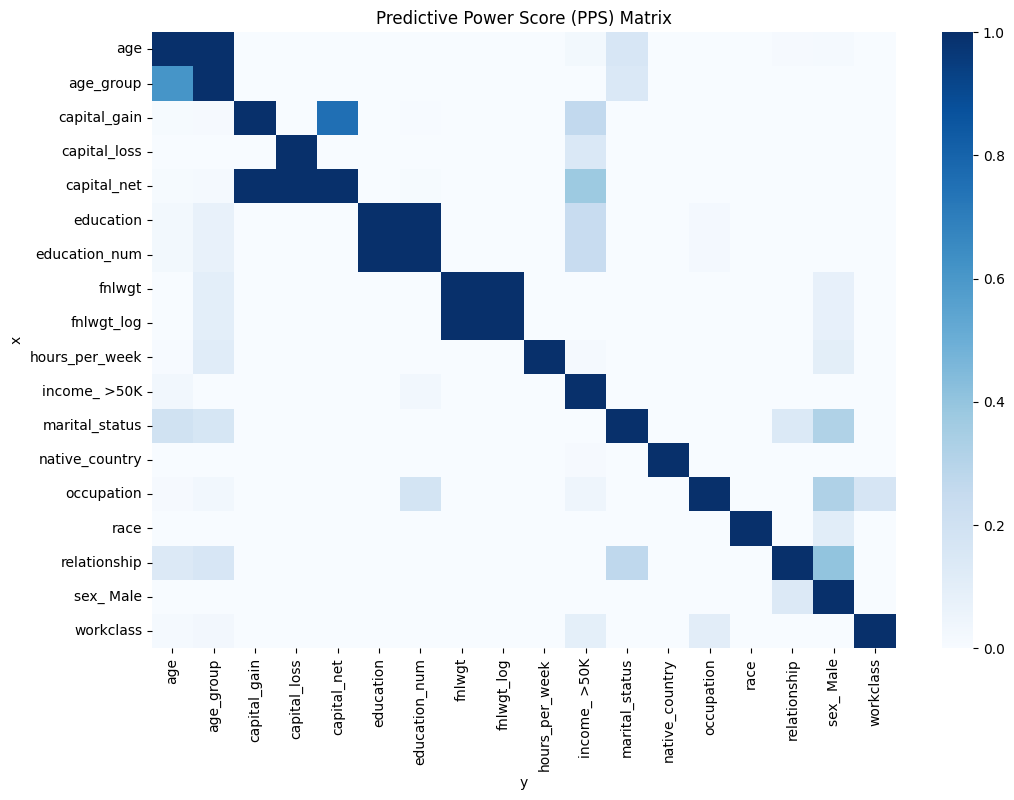

In [12]:
# (b) Predictive Power Score (PPS)

import ppscore as pps
# Compute PPS matrix
pps_matrix = pps.matrix(df_no_outliers)

# PPS Heatmap
# PPS Heatmap (fixed pivot call)
plt.figure(figsize=(12,8))
sns.heatmap(
    pps_matrix.pivot(index="x", columns="y", values="ppscore"),
    cmap="Blues", annot=False
)
plt.title("Predictive Power Score (PPS) Matrix")
plt.show()

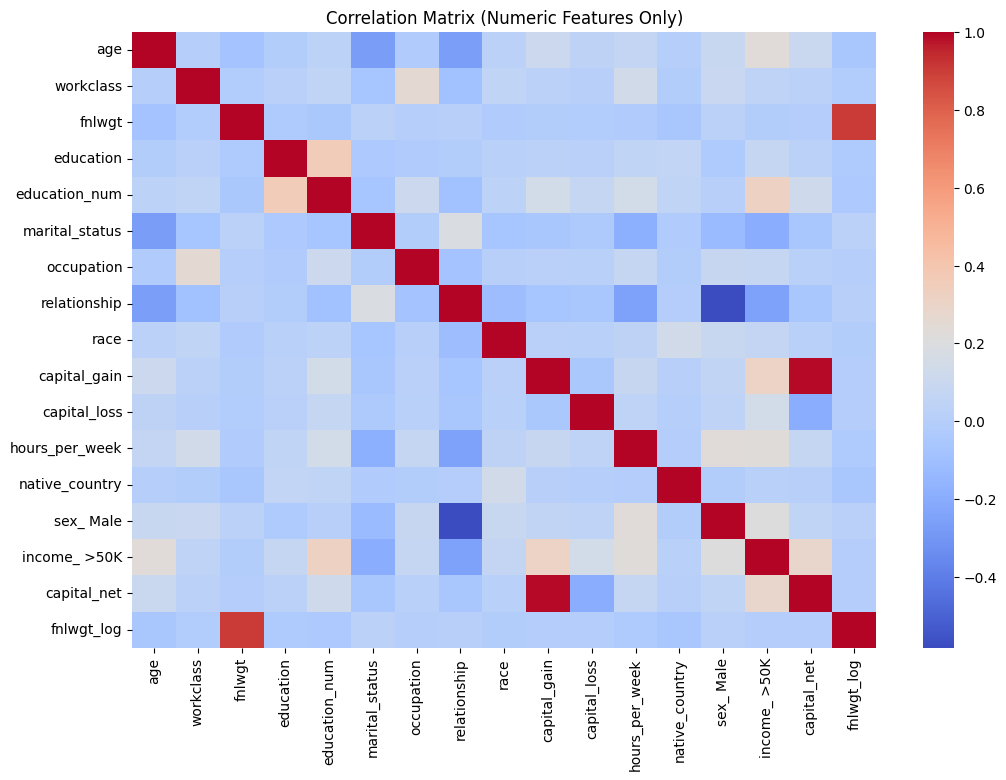

In [13]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_no_outliers.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()